# Forward Noising Intuition: q(x_t | x_0)

This notebook builds visual intuition for the **forward diffusion process** -- the part of a
diffusion model that gradually destroys structure in data by adding Gaussian noise, step by step,
until the data is indistinguishable from pure noise.

We use a tiny 2D toy dataset (two interleaving moons) so the whole process is visible as a
scatter plot. No neural network, no training -- just the math of the forward process.

**What you should walk away with:**

- The forward process is a *fixed* (non-learned) Markov chain that adds a little Gaussian noise at each step.
- There is a closed form that lets you jump directly to any timestep `t` without simulating every step in between.
- A single schedule term, `alpha_bar_t`, controls how much original signal survives at step `t`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

np.random.seed(0)


## 1. The data: x_0

We sample ~2000 points from `make_moons` with a small amount of intrinsic noise, then
**standardize** each dimension to zero mean and unit variance.

Standardizing matters: the forward process drives the cloud toward a *standard* unit Gaussian
`N(0, I)`. If the data started far from zero mean / unit variance, the early scatter plots would
be misleading about how close to N(0, I) we end up. Starting standardized makes the 'melting into
a unit Gaussian' picture honest.


In [2]:
n_samples = 2000
x0_raw, _ = make_moons(n_samples=n_samples, noise=0.05, random_state=0)

# Standardize each dimension to mean 0, std 1.
x0 = (x0_raw - x0_raw.mean(axis=0)) / x0_raw.std(axis=0)

print('x0 shape:', x0.shape)
print('x0 mean per dim:', np.round(x0.mean(axis=0), 4))
print('x0 std  per dim:', np.round(x0.std(axis=0), 4))


x0 shape: (2000, 2)
x0 mean per dim: [-0.  0.]
x0 std  per dim: [1. 1.]


## 2. The noise schedule: beta_t and alpha_bar_t

The forward process adds noise one step at a time:

    x_t = sqrt(1 - beta_t) * x_{t-1} + sqrt(beta_t) * eps,   eps ~ N(0, I)

Here `beta_t` is the **variance of the noise injected at step t**. We use a simple *linear*
schedule: `beta_t` rises linearly from a tiny value at t=0 to a larger value at t=T-1. Small betas
early mean the data is corrupted gently at first; larger betas later finish the job quickly.

Two derived quantities make the math clean:

- `alpha_t  = 1 - beta_t`               (fraction of signal kept at this single step)
- `alpha_bar_t = prod_{s=1..t} alpha_s` (cumulative product -- fraction of the *original* signal
  variance that survives after t steps)

`alpha_bar_t` is the star of the show: it summarizes the entire history of noising up to step `t`
in one number per timestep.


In [3]:
T = 200

# Linear beta schedule (the values used in the original DDPM paper, scaled to T).
beta_start = 1e-4
beta_end = 0.02
betas = np.linspace(beta_start, beta_end, T)

alphas = 1.0 - betas
alpha_bar = np.cumprod(alphas)

print('T =', T)
print('beta_0   =', betas[0],  '  beta_{T-1}   =', betas[-1])
print('abar_0   =', round(float(alpha_bar[0]), 5),
      '  abar_{T-1} =', round(float(alpha_bar[-1]), 5))


T = 200
beta_0   = 0.0001   beta_{T-1}   = 0.02
abar_0   = 0.9999   abar_{T-1} = 0.13218


## 3. The closed form: jump straight to any t

Because each step adds independent Gaussian noise, you can compose all `t` steps analytically.
The result is the key identity of the forward process:

    x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps,   eps ~ N(0, I)

Read it as a weighted blend:

- `sqrt(alpha_bar_t)` scales the **original data** x_0. As `t` grows, `alpha_bar_t` shrinks
  toward 0, so the signal fades.
- `sqrt(1 - alpha_bar_t)` scales **fresh standard noise**. As `t` grows, this weight rises
  toward 1, so noise takes over.

**Why noise accumulates:** each step keeps only `alpha_t < 1` of the previous signal, so after `t`
steps the surviving fraction is the *product* `alpha_bar_t = alpha_1 * alpha_2 * ... * alpha_t`.
A product of numbers each slightly below 1 decays toward 0 -- the signal compounds away while the
injected variance compounds up. The two weights are tied: their squares always sum to 1
(`alpha_bar_t + (1 - alpha_bar_t) = 1`), so the total variance stays at 1 and x_t never blows up;
it just trades signal for noise.

At `t = T-1`, `alpha_bar_t` is near 0, so `x_t` is almost pure `N(0, I)` -- all data structure is gone.


In [4]:
def q_sample(x_start, t, alpha_bar):
    """Sample x_t ~ q(x_t | x_0) via the closed form for an integer timestep t.

    x_start    : (N, D) array of clean data x_0
    t          : int timestep index in [0, T-1]
    alpha_bar  : (T,) cumulative product schedule
    """
    abar_t = alpha_bar[t]
    eps = np.random.randn(*x_start.shape)
    return np.sqrt(abar_t) * x_start + np.sqrt(1.0 - abar_t) * eps

# Sanity check: at t=0 we keep almost all signal; at t=T-1 we keep almost none.
x_t0 = q_sample(x0, 0, alpha_bar)
x_tT = q_sample(x0, T - 1, alpha_bar)
print('var(x_0)      per dim:', np.round(x0.var(axis=0), 3))
print('var(x_t=0)    per dim:', np.round(x_t0.var(axis=0), 3))
print('var(x_t=T-1)  per dim:', np.round(x_tT.var(axis=0), 3),
      ' (-> close to 1.0, i.e. N(0, I))')


var(x_0)      per dim: [1. 1.]
var(x_t=0)    per dim: [0.999 1.   ]
var(x_t=T-1)  per dim: [1.005 0.959]  (-> close to 1.0, i.e. N(0, I))


## 4. Watch the data melt into a Gaussian

Below we draw `x_t` at six timesteps spanning the schedule: `t in {0, T/8, T/4, T/2, 3T/4, T-1}`.

At `t=0` you can still read the two moons. By the middle of the schedule the arcs smear out, and
by `t=T-1` the cloud is an isotropic blob centered at the origin -- a unit Gaussian. The dashed
unit circle (radius 1, ~1 standard deviation of N(0, I)) is drawn for reference so you can see the
final cloud settle into it.


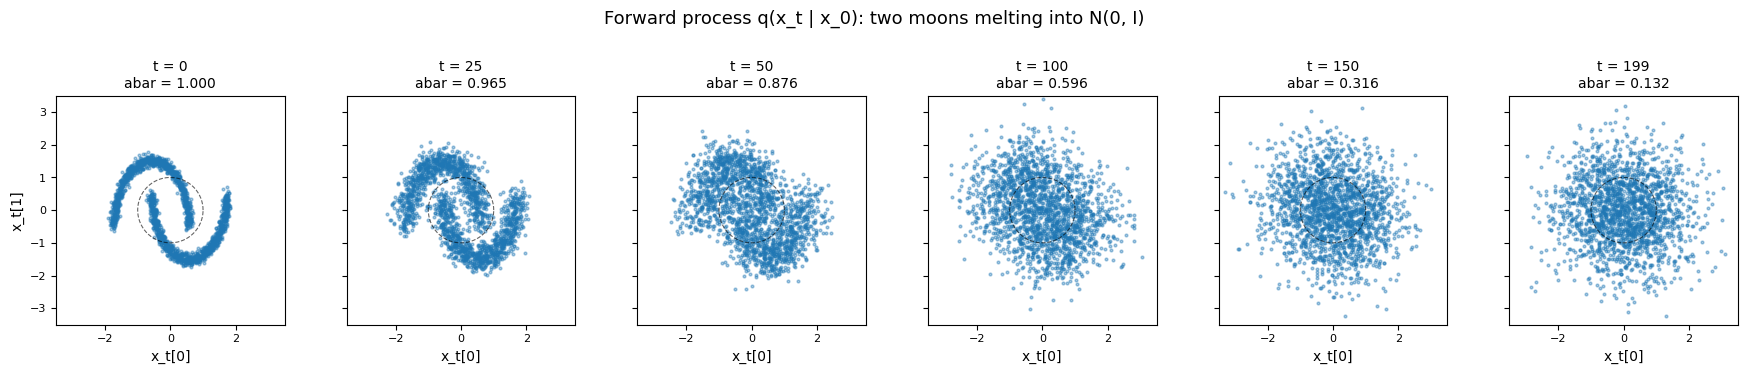

In [5]:
timesteps = [0, T // 8, T // 4, T // 2, (3 * T) // 4, T - 1]

fig, axes = plt.subplots(1, len(timesteps), figsize=(18, 3.2), sharex=True, sharey=True)

# Reference unit circle (1 std of a standard 2D Gaussian).
theta = np.linspace(0, 2 * np.pi, 200)
circle_x, circle_y = np.cos(theta), np.sin(theta)

for ax, t in zip(axes, timesteps):
    x_t = q_sample(x0, t, alpha_bar)
    ax.scatter(x_t[:, 0], x_t[:, 1], s=4, alpha=0.4, color='tab:blue')
    ax.plot(circle_x, circle_y, 'k--', linewidth=0.8, alpha=0.6)
    ax.set_title('t = {}\nabar = {:.3f}'.format(t, float(alpha_bar[t])), fontsize=10)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('x_t[1]')
for ax in axes:
    ax.set_xlabel('x_t[0]')

fig.suptitle('Forward process q(x_t | x_0): two moons melting into N(0, I)', y=1.08, fontsize=13)
fig.tight_layout()
plt.show()


## 5. What alpha_bar_t controls

The scatter row is governed entirely by the curve below. `alpha_bar_t` is the **signal-retention
schedule**: at each timestep it tells you what fraction of the original data variance is still
present (the rest has been replaced by noise).

- Near `t=0`, `alpha_bar_t ~ 1`: almost all signal, the moons are intact.
- The curve falls fastest in the middle, where the linear beta schedule is doing the most damage
  per step -- this is where the scatter plots change most dramatically.
- Near `t=T-1`, `alpha_bar_t ~ 0`: almost no signal, the cloud is pure noise.

A diffusion *model* later learns to invert exactly this curve -- to walk back up from `alpha_bar ~ 0`
to `alpha_bar ~ 1`, one denoising step at a time. Understanding the shape of this schedule is the
foundation for everything that follows.


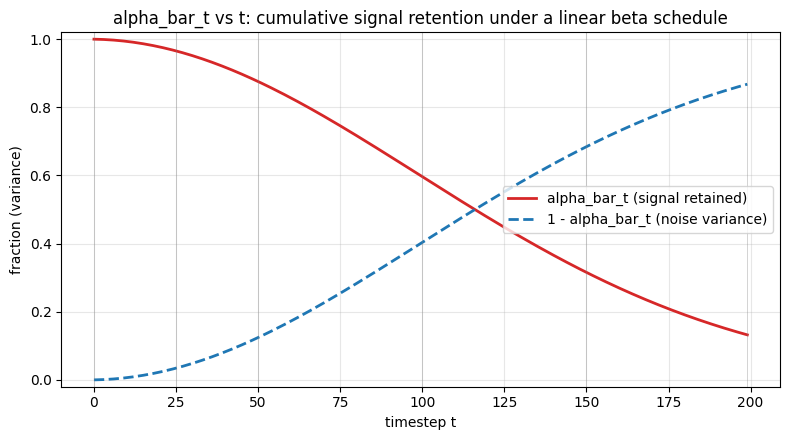

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ts = np.arange(T)
ax.plot(ts, alpha_bar, color='tab:red', linewidth=2, label='alpha_bar_t (signal retained)')
ax.plot(ts, 1.0 - alpha_bar, color='tab:blue', linewidth=2, linestyle='--',
        label='1 - alpha_bar_t (noise variance)')

# Mark the timesteps used in the scatter row.
for t in timesteps:
    ax.axvline(t, color='gray', linewidth=0.6, alpha=0.4)

ax.set_xlabel('timestep t')
ax.set_ylabel('fraction (variance)')
ax.set_title('alpha_bar_t vs t: cumulative signal retention under a linear beta schedule')
ax.set_ylim(-0.02, 1.02)
ax.legend(loc='center right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Recap

- The forward process `q(x_t | x_0)` adds Gaussian noise on a fixed linear `beta` schedule.
- The closed form `x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps` lets us jump to any
  timestep in one shot, with no step-by-step simulation.
- Noise accumulates because `alpha_bar_t` is a *product* of per-step retention factors, each < 1,
  so it decays toward 0 while keeping total variance pinned at 1.
- `alpha_bar_t` is the single dial controlling how much original signal survives at step `t` -- the
  exact quantity a trained diffusion model learns to reverse.
